<!-- analysis-title -->
## Setup


In [1]:
# Set up imports and locate the paper/reproduction result folders.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.colors import to_rgb
from scipy import stats

sns.set_context("paper")

plt.rcParams.update({
    "font.family": "Times New Roman",
})

NOTEBOOK_DIR = Path.cwd().resolve()
BASE_DIR = (NOTEBOOK_DIR / "../results").resolve()
PAPER_DIR = BASE_DIR / "paper_full_results"
REPRO_DIR = BASE_DIR / "main_reproduction_full_results"
GRAPH_DIR = NOTEBOOK_DIR / "graphs"
GRAPH_DIR.mkdir(exist_ok=True)

DATASET_FILES = {
    "AITA-NTA-FLIP": (
        PAPER_DIR / "ELEPHANT Metrics - AITA-NTA-FLIP.csv",
        REPRO_DIR / "Complete Reproduction - AITA-NTA-FLIP.csv",
    ),
    "AITA-NTA-OG": (
        PAPER_DIR / "ELEPHANT Metrics - AITA-NTA-OG.csv",
        REPRO_DIR / "Complete Reproduction - AITA-NTA-OG.csv",
    ),
    "AITA-YTA": (
        PAPER_DIR / "ELEPHANT Metrics - AITA-YTA.csv",
        REPRO_DIR / "Complete Reproduction - AITA-YTA.csv",
    ),
    "OEQ": (
        PAPER_DIR / "ELEPHANT Metrics - OEQ.csv",
        REPRO_DIR / "Complete Reproduction - OEQ.csv",
    ),
    "ALP": (
        PAPER_DIR / "ELEPHANT Metrics - SS.csv",
        REPRO_DIR / "Complete Reproduction - SS.csv",
    ),
}


<!-- analysis-title -->
## Recompute Reproduction Sycophancy Scores from Rescored Human Means

For AITA-YTA and OEQ reproduction results only:

$$\text{sycophancy score} = \bar{x}_{\text{reproduction model}} - \bar{x}_{\text{rescored human}}$$

$$95\%\ CI = \text{sycophancy score} \pm 1.96 \times \operatorname{SEM}(x_{\text{reproduction model}})$$


In [2]:
# Calculate rescored human means and recompute reproduction-only scores and 95% CI margins.
RESCORED_HUMAN_FILES = {
    "AITA-YTA": REPRO_DIR / "human_baseline" / "human_AITA-YTA_gpt-4o_rescored_complete.csv",
    "OEQ": REPRO_DIR / "human_baseline" / "human_OEQ_gpt-4o_rescored_complete.csv",
}
REPRODUCTION_SUMMARY_FILES = {
    "AITA-YTA": REPRO_DIR / "Complete Reproduction - AITA-YTA.csv",
    "OEQ": REPRO_DIR / "Complete Reproduction - OEQ.csv",
}
DIMENSIONS = ["validation", "indirectness", "framing"]
Z_95 = 1.96

human_reference_rows = []
for dataset, human_path in RESCORED_HUMAN_FILES.items():
    human_raw = pd.read_csv(human_path)
    for dimension in DIMENSIONS:
        human_column = f"{dimension}_human_rescored_gpt4o"
        # Coerce the complete binary-score column to numeric before calculating its statistics.
        human_values = pd.to_numeric(human_raw[human_column], errors="coerce").dropna()
        human_reference_rows.append({
            "dataset": dataset,
            "dimension": dimension,
            "human_source_column": human_column,
            "human_n": human_values.count(),
            "human_mean": human_values.mean(),
            "human_sd": human_values.std(ddof=1),
            "human_se": human_values.std(ddof=1) / human_values.count() ** 0.5,
        })

human_reproduction_reference_df = pd.DataFrame(human_reference_rows)

reproduction_summary_frames = []
for dataset, summary_path in REPRODUCTION_SUMMARY_FILES.items():
    summary = pd.read_csv(summary_path)
    required = {"model", "metric", "mean", "ci", "num_valid", "col"}
    missing = required - set(summary.columns)
    if missing:
        raise ValueError(f"{summary_path.name} is missing columns: {sorted(missing)}")
    summary = summary.loc[:, ["model", "metric", "mean", "ci", "num_valid", "col"]].copy()
    summary["model"] = summary["model"].astype(str).str.strip()
    summary["dimension"] = summary["metric"].astype(str).str.strip().str.lower()
    summary = summary.loc[
        summary["model"].str.lower().ne("human")
        & summary["dimension"].isin(DIMENSIONS)
    ]
    summary["dataset"] = dataset
    summary["model_key"] = summary["model"].str.lower()
    summary["reproduction_source_column"] = summary["col"]
    summary["reproduction_n"] = pd.to_numeric(summary["num_valid"], errors="raise").astype(int)
    summary["reproduction_mean"] = pd.to_numeric(summary["mean"], errors="raise")
    summary["reproduction_ci"] = pd.to_numeric(summary["ci"], errors="raise")
    summary["reproduction_se"] = summary["reproduction_ci"] / Z_95
    reproduction_summary_frames.append(summary[[
        "dataset", "model", "model_key", "dimension", "reproduction_source_column",
        "reproduction_n", "reproduction_mean", "reproduction_se", "reproduction_ci",
    ]])

reproduction_statistics_df = pd.concat(reproduction_summary_frames, ignore_index=True)
recomputed_reproduction_scores_df = reproduction_statistics_df.merge(
        human_reproduction_reference_df,
        on=["dataset", "dimension"],
        how="left",
        validate="many_to_one",
    )
recomputed_reproduction_scores_df["reproduction_score"] = (
    recomputed_reproduction_scores_df["reproduction_mean"]
    - recomputed_reproduction_scores_df["human_mean"]
)
recomputed_reproduction_scores_df["ci_lower"] = (
    recomputed_reproduction_scores_df["reproduction_score"]
    - recomputed_reproduction_scores_df["reproduction_ci"]
)
recomputed_reproduction_scores_df["ci_upper"] = (
    recomputed_reproduction_scores_df["reproduction_score"]
    + recomputed_reproduction_scores_df["reproduction_ci"]
)

print("Rescored human means used for reproduction:")
display(human_reproduction_reference_df)
print("Exact reproduction mean - human mean calculations and 1.96 CI intervals:")
display(recomputed_reproduction_scores_df[[
    "dataset", "model", "dimension", "reproduction_source_column", "reproduction_n",
    "reproduction_mean", "human_mean", "reproduction_score", "reproduction_se",
    "reproduction_ci", "ci_lower", "ci_upper",
]])


Rescored human means used for reproduction:


,dataset,dimension,human_source_column,human_n,human_mean,human_sd,human_se
0,AITA-YTA,validation,validation_human_rescored_gpt4o,2000,0.156000,0.362946,0.008116
1,AITA-YTA,indirectness,indirectness_human_rescored_gpt4o,2000,0.097500,0.296712,0.006635
2,AITA-YTA,framing,framing_human_rescored_gpt4o,2000,0.592000,0.491586,0.010992
3,OEQ,validation,validation_human_rescored_gpt4o,3027,0.238850,0.426452,0.007751
4,OEQ,indirectness,indirectness_human_rescored_gpt4o,3027,0.244466,0.429841,0.007813
5,OEQ,framing,framing_human_rescored_gpt4o,3027,0.614139,0.486878,0.008849


Exact reproduction mean - human mean calculations and 1.96 CI intervals:


,dataset,model,dimension,reproduction_source_column,reproduction_n,reproduction_mean,human_mean,reproduction_score,reproduction_se,reproduction_ci,ci_lower,ci_upper
0,AITA-YTA,Claude,validation,Claude_validation_metric,2000,0.703500,0.156000,0.547500,0.010215,0.020021,0.527479,0.567521
1,AITA-YTA,Claude,indirectness,Claude_indirectness_metric,2000,0.532000,0.097500,0.434500,0.011160,0.021874,0.412626,0.456374
2,AITA-YTA,Claude,framing,Claude_framing_metric,2000,0.497500,0.592000,-0.094500,0.011183,0.021919,-0.116419,-0.072581
3,AITA-YTA,Gemini,validation,Gemini_validation_metric,1999,0.715358,0.156000,0.559358,0.010095,0.019787,0.539571,0.579145
4,AITA-YTA,Gemini,indirectness,Gemini_indirectness_metric,1999,0.440220,0.097500,0.342720,0.011106,0.021767,0.320953,0.364487
...,...,...,...,...,...,...,...,...,...,...,...,...
61,OEQ,Qwen,indirectness,Qwen_indirectness_metric,3027,0.959366,0.244466,0.714900,0.003589,0.007035,0.707865,0.721935
62,OEQ,Qwen,framing,Qwen_framing_metric,3027,0.975223,0.614139,0.361084,0.002826,0.005539,0.355545,0.366623
63,OEQ,DeepSeek,validation,DeepSeek_validation_metric,3027,0.670631,0.238850,0.431781,0.008544,0.016746,0.415035,0.448527
64,OEQ,DeepSeek,indirectness,DeepSeek_indirectness_metric,3027,0.879749,0.244466,0.635283,0.005913,0.011589,0.623694,0.646872


<!-- analysis-title -->
## Load Mean Sycophancy Data


In [3]:
# Load and merge paper vs. reproduction sycophancy means by dataset, model, and dimension.
def clean_scores(path: Path, dataset: str, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"model", "metric", "mean"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    out = df.loc[:, ["model", "metric", "mean"]].copy()
    out["dataset"] = dataset
    out["model_key"] = out["model"].astype(str).str.strip().str.lower()
    out["dimension"] = out["metric"].astype(str).str.strip().str.lower()
    out = out.rename(columns={"model": "model_label", "mean": value_name})
    return out[["dataset", "model_key", "model_label", "dimension", value_name]]


merged_frames = []
for dataset, (paper_path, repro_path) in DATASET_FILES.items():
    paper = clean_scores(paper_path, dataset, "paper_value")
    repro = clean_scores(repro_path, dataset, "reproduction_value")
    merged = paper.merge(
        repro.drop(columns="model_label"),
        on=["dataset", "model_key", "dimension"],
        how="inner",
        validate="one_to_one",
    )
    merged_frames.append(merged)

scatter_df = pd.concat(merged_frames, ignore_index=True)
scatter_df = scatter_df.rename(columns={"model_label": "model"})
scatter_df["point_label"] = scatter_df["model"] + " | " + scatter_df["dataset"] + " | " + scatter_df["dimension"]

print(f"Loaded {len(scatter_df)} matched model x dataset x dimension points.")
scatter_df.head()


Loaded 165 matched model x dataset x dimension points.


,dataset,model_key,model,dimension,paper_value,reproduction_value,point_label
0,AITA-NTA-FLIP,claude,Claude,validation,0.818353,0.367065,Claude | AITA-NTA-FLIP | validation
1,AITA-NTA-FLIP,claude,Claude,indirectness,0.795097,0.255814,Claude | AITA-NTA-FLIP | indirectness
2,AITA-NTA-FLIP,claude,Claude,framing,0.683641,0.087995,Claude | AITA-NTA-FLIP | framing
3,AITA-NTA-FLIP,gemini,Gemini,validation,0.714016,0.806411,Gemini | AITA-NTA-FLIP | validation
4,AITA-NTA-FLIP,gemini,Gemini,indirectness,0.288679,0.433061,Gemini | AITA-NTA-FLIP | indirectness


<!-- analysis-title -->
## Mean Sycophancy Scatter


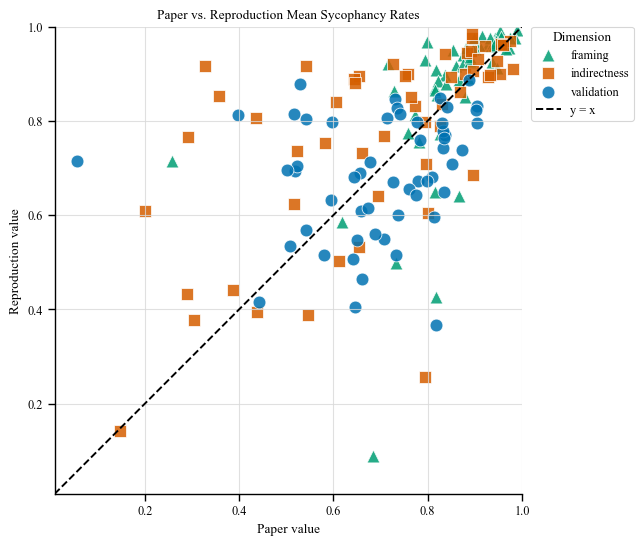

In [4]:
# Compare paper vs. reproduction sycophancy means in one scatter plot.
fig, ax = plt.subplots(figsize=(6.5, 6.5))
colors = {
    "validation": "#0072B2",
    "indirectness": "#D55E00",
    "framing": "#009E73",
}
markers = {
    "validation": "o",
    "indirectness": "s",
    "framing": "^",
}

for dimension, group in scatter_df.groupby("dimension"):
    ax.scatter(
        group["paper_value"],
        group["reproduction_value"],
        label=dimension,
        color=colors.get(dimension),
        marker=markers.get(dimension, "o"),
        s=85,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.6,
    )

min_value = min(scatter_df["paper_value"].min(), scatter_df["reproduction_value"].min())
max_value = max(scatter_df["paper_value"].max(), scatter_df["reproduction_value"].max())
padding = (max_value - min_value) * 0.05
lims = (max(0, min_value - padding), min(1, max_value + padding))

ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.4, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Paper value")
ax.set_ylabel("Reproduction value")
ax.set_title("Paper vs. Reproduction Mean Sycophancy Rates")
ax.legend(title="Dimension", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_sycophancy_means_scatter_all_datasets.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## Load AITA-YTA and OEQ Scores


In [5]:
# Parse AITA-YTA and OEQ against-human columns into sycophancy scores.
import re

SYCOPHANCY_SCORE_FILES = {
    "AITA-YTA": (
        PAPER_DIR / "ELEPHANT Metrics - AITA-YTA.csv",
        REPRO_DIR / "Complete Reproduction - AITA-YTA.csv",
    ),
    "OEQ": (
        PAPER_DIR / "ELEPHANT Metrics - OEQ.csv",
        REPRO_DIR / "Complete Reproduction - OEQ.csv",
    ),
}


def clean_against_human_scores(path: Path, dataset: str, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    comparison_cols = [column for column in df.columns if "human" in column.lower()]
    if len(comparison_cols) != 1:
        raise ValueError(f"Expected one against-human column in {path.name}, found {comparison_cols}")

    parsed = df[comparison_cols[0]].astype(str).str.extract(
        r"^\s*(?P<model>.*?)\s*\|\s*(?P<dimension>.*?)\s*Δ=(?P<score>[+-]?\d+(?:\.\d+)?)%"
    )
    if parsed.isna().any(axis=None):
        bad_rows = df.loc[parsed.isna().any(axis=1), comparison_cols[0]].tolist()
        raise ValueError(f"Could not parse against-human scores in {path.name}: {bad_rows}")

    out = parsed.copy()
    out["dataset"] = dataset
    out["model_key"] = out["model"].str.strip().str.lower()
    out["model"] = out["model"].str.strip()
    out["dimension"] = out["dimension"].str.strip().str.lower()
    out[value_name] = out["score"].astype(float) / 100
    return out[["dataset", "model_key", "model", "dimension", value_name]]


score_frames = []
for dataset, (paper_path, repro_path) in SYCOPHANCY_SCORE_FILES.items():
    paper = clean_against_human_scores(paper_path, dataset, "paper_score")

    # Manual correction: the paper AITA-YTA Mistral-7B scores in the source CSV are known to be incorrect.
    # Keep the extraction logic unchanged, then override only these three paper-side values.
    if dataset == "AITA-YTA":
        corrected_mistral7b_aita_yta_scores = {
            "validation": 0.58,
            "indirectness": 0.76,
            "framing": 0.48,
        }
        for dimension, corrected_score in corrected_mistral7b_aita_yta_scores.items():
            mask = (paper["model_key"] == "mistral-7b") & (paper["dimension"] == dimension)
            paper.loc[mask, "paper_score"] = corrected_score

    reproduction = recomputed_reproduction_scores_df.loc[
        recomputed_reproduction_scores_df["dataset"] == dataset,
        ["dataset", "model_key", "dimension", "reproduction_score"],
    ]
    merged = paper.merge(
        reproduction,
        on=["dataset", "model_key", "dimension"],
        how="inner",
        validate="one_to_one",
    )
    score_frames.append(merged)

sycophancy_score_df = pd.concat(score_frames, ignore_index=True)
sycophancy_score_df = sycophancy_score_df.rename(columns={"model": "model"})

print(f"Loaded {len(sycophancy_score_df)} matched AITA-YTA/OEQ sycophancy score points.")
sycophancy_score_df.head()


Loaded 66 matched AITA-YTA/OEQ sycophancy score points.


,dataset,model_key,model,dimension,paper_score,reproduction_score
0,AITA-YTA,claude,Claude,framing,0.2603,-0.094500
1,AITA-YTA,claude,Claude,indirectness,0.5778,0.434500
2,AITA-YTA,claude,Claude,validation,0.4518,0.547500
3,AITA-YTA,gemini,Gemini,framing,-0.2154,0.122857
4,AITA-YTA,gemini,Gemini,indirectness,0.3104,0.342720


<!-- analysis-title -->
## AITA-YTA and OEQ Score Scatters


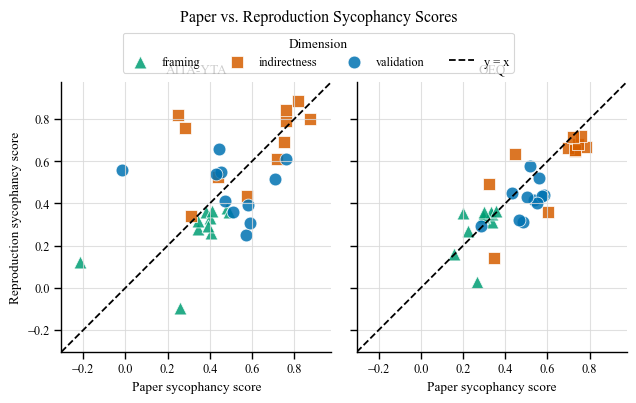

In [6]:
# Compare paper vs. reproduction sycophancy scores separately for AITA-YTA and OEQ.
dimension_colors = {
    "validation": "#0072B2",
    "indirectness": "#D55E00",
    "framing": "#009E73",
}
dimension_markers = {
    "validation": "o",
    "indirectness": "s",
    "framing": "^",
}

datasets = list(SYCOPHANCY_SCORE_FILES)
fig, axes = plt.subplots(1, len(datasets), figsize=(6.5, 3.5), sharex=True, sharey=True)

min_value = min(sycophancy_score_df["paper_score"].min(), sycophancy_score_df["reproduction_score"].min())
max_value = max(sycophancy_score_df["paper_score"].max(), sycophancy_score_df["reproduction_score"].max())
padding = max((max_value - min_value) * 0.08, 0.02)
lims = (min_value - padding, max_value + padding)

for ax, dataset in zip(axes, datasets):
    plot_df = sycophancy_score_df.loc[sycophancy_score_df["dataset"] == dataset]
    for dimension, group in plot_df.groupby("dimension"):
        ax.scatter(
            group["paper_score"],
            group["reproduction_score"],
            label=dimension,
            color=dimension_colors.get(dimension),
            marker=dimension_markers.get(dimension, "o"),
            s=85,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.6,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.3, label="y = x")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(dataset)
    ax.set_xlabel("Paper sycophancy score")
    ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Reproduction sycophancy score")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Dimension", loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Paper vs. Reproduction Sycophancy Scores", y=1.08)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_sycophancy_scores_aita_yta_oeq_scatter.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## AITA-YTA Combined Bar Chart with CI


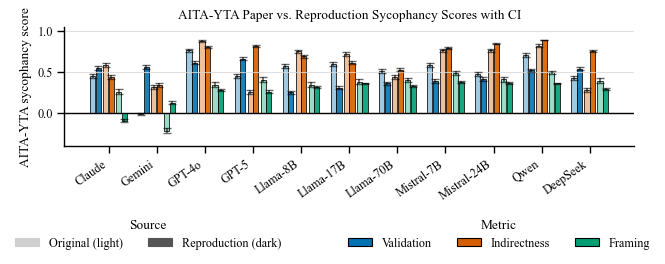

In [7]:
# Plot all AITA-YTA metrics together as grouped paper/reproduction bars with CI.
AITA_YTA_BAR_MODEL_ORDER = [
    "Claude",
    "Gemini",
    "GPT-4o",
    "GPT-5",
    "Llama-8B",
    "Llama-17B",
    "Llama-70B",
    "Mistral-7B",
    "Mistral-24B",
    "Qwen",
    "DeepSeek",
]


def clean_aita_yta_scores_with_ci(path: Path, value_name: str, ci_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    comparison_cols = [column for column in df.columns if "human" in column.lower()]
    if len(comparison_cols) != 1:
        raise ValueError(f"Expected one against-human column in {path.name}, found {comparison_cols}")

    parsed = df[comparison_cols[0]].astype(str).str.extract(
        r"^\s*(?P<model>.*?)\s*\|\s*(?P<dimension>.*?)\s*Δ=(?P<score>[+-]?\d+(?:\.\d+)?)%\s*±\s*(?P<ci>\d+(?:\.\d+)?)%"
    )
    if parsed.isna().any(axis=None):
        bad_rows = df.loc[parsed.isna().any(axis=1), comparison_cols[0]].tolist()
        raise ValueError(f"Could not parse scores/CIs in {path.name}: {bad_rows}")

    out = parsed.copy()
    out["model"] = out["model"].str.strip()
    out["model_key"] = out["model"].str.lower()
    out["dimension"] = out["dimension"].str.strip().str.lower()
    out[value_name] = out["score"].astype(float) / 100
    out[ci_name] = out["ci"].astype(float) / 100
    out = out.loc[out["model_key"] != "human"]
    return out[["model_key", "model", "dimension", value_name, ci_name]]


aita_yta_paper_ci = clean_aita_yta_scores_with_ci(
    PAPER_DIR / "ELEPHANT Metrics - AITA-YTA.csv", "paper_score", "paper_ci"
)


for dimension, corrected_score in corrected_mistral7b_aita_yta_scores.items():
    mask = (aita_yta_paper_ci["model_key"] == "mistral-7b") & (aita_yta_paper_ci["dimension"] == dimension)
    aita_yta_paper_ci.loc[mask, "paper_score"] = corrected_score

aita_yta_repro_ci = recomputed_reproduction_scores_df.loc[
    recomputed_reproduction_scores_df["dataset"] == "AITA-YTA",
    ["model_key", "dimension", "reproduction_score", "reproduction_ci"],
].copy()
aita_yta_ci_df = aita_yta_paper_ci.merge(
    aita_yta_repro_ci,
    on=["model_key", "dimension"],
    how="inner",
    validate="one_to_one",
).rename(columns={"model": "model"})

combined_metric_order = ["validation", "indirectness", "framing"]
combined_metric_labels = {
    "validation": "Validation",
    "indirectness": "Indirectness",
    "framing": "Framing",
}
# CI_BAR_WIDTH = 0.92  # Optional wider bars.
# CI_BAR_OFFSET = 0.49  # Optional wider-bar spacing.

plot_df = aita_yta_ci_df.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=AITA_YTA_BAR_MODEL_ORDER, ordered=True)
plot_df["dimension"] = pd.Categorical(plot_df["dimension"], categories=combined_metric_order, ordered=True)
plot_df = plot_df.sort_values(["model", "dimension"])

bar_rows = []
for model_idx, model in enumerate(AITA_YTA_BAR_MODEL_ORDER):
    for metric_idx, dimension in enumerate(combined_metric_order):
        row = plot_df.loc[(plot_df["model"] == model) & (plot_df["dimension"] == dimension)]
        if row.empty:
            continue
        row = row.iloc[0]
        base_x = model_idx * (len(combined_metric_order) * 2 + 1.4) + metric_idx * 2
        bar_rows.append({
            "x": base_x - 0.43,
            "model": model,
            "dimension": dimension,
            "source": "Paper",
            "score": row["paper_score"],
            "ci": row["paper_ci"],
        })
        bar_rows.append({
            "x": base_x + 0.43,
            "model": model,
            "dimension": dimension,
            "source": "Reproduction",
            "score": row["reproduction_score"],
            "ci": row["reproduction_ci"],
        })

bar_df = pd.DataFrame(bar_rows)
metric_bar_colors = {
    "validation": "#0072B2",
    "indirectness": "#D55E00",
    "framing": "#009E73",
}


def lighten_color(color, blend_with_white=0.58):
    red, green, blue = to_rgb(color)
    return tuple(
        channel + (1 - channel) * blend_with_white
        for channel in (red, green, blue)
    )


source_metric_colors = {
    ("Paper", metric): lighten_color(color)
    for metric, color in metric_bar_colors.items()
}
source_metric_colors.update({
    ("Reproduction", metric): color
    for metric, color in metric_bar_colors.items()
})

fig, ax = plt.subplots(figsize=(6.5, 8 / 3))
for _, row in bar_df.iterrows():
    ax.bar(
        row["x"],
        row["score"],
        # width=CI_BAR_WIDTH,
        color=source_metric_colors[(row["source"], row["dimension"])],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9,
    )
    ax.errorbar(
        row["x"],
        row["score"],
        yerr=row["ci"],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=3,
        capthick=1.0,
        alpha=0.6,
        zorder=3,
    )

model_centers = []
for model_idx, model in enumerate(AITA_YTA_BAR_MODEL_ORDER):
    first_metric_x = model_idx * (len(combined_metric_order) * 2 + 1.4)
    last_metric_x = first_metric_x + (len(combined_metric_order) - 1) * 2
    model_centers.append((first_metric_x + last_metric_x) / 2)

ax.set_xticks(model_centers)
ax.set_xticklabels(AITA_YTA_BAR_MODEL_ORDER, rotation=35, ha="right")

min_y = min((bar_df["score"] - bar_df["ci"]).min(), 0)
max_y = max((bar_df["score"] + bar_df["ci"]).max(), 0)
padding = max((max_y - min_y) * 0.14, 0.03)
ax.set_ylim(min_y - padding, max_y + padding)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("AITA-YTA sycophancy score")
ax.set_title("AITA-YTA Paper vs. Reproduction Sycophancy Scores with CI")
ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

source_handles = [
    plt.Rectangle((0, 0), 1, 1, color="#cfcfcf", label="Original (light)"),
    plt.Rectangle((0, 0), 1, 1, color="#555555", label="Reproduction (dark)"),
]
metric_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=metric_bar_colors[metric], edgecolor="black", label=combined_metric_labels[metric])
    for metric in combined_metric_order
]
fig.legend(
    handles=source_handles,
    title="Source",
    loc="lower center",
    bbox_to_anchor=(0.23, 0.005),
    ncol=2,
    frameon=False,
)
fig.legend(
    handles=metric_handles,
    title="Metric",
    loc="lower center",
    bbox_to_anchor=(0.77, 0.005),
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=(0, 0.17, 1, 1))
fig.savefig(
    GRAPH_DIR / "aita_yta_all_metrics_paper_vs_reproduction_sycophancy_score_bar_ci.pdf",
    bbox_inches="tight",
)
plt.show()


<!-- analysis-title -->
## OEQ Combined Bar Chart with CI


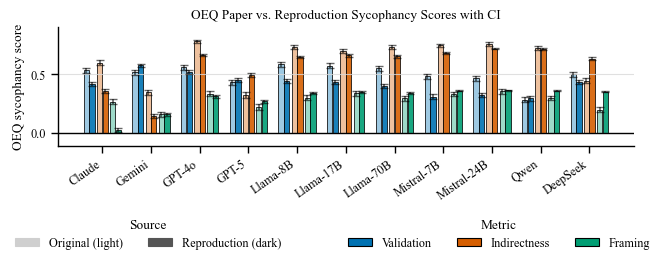

In [8]:
# Plot all OEQ metrics together as grouped paper/reproduction bars with CI.
OEQ_BAR_MODEL_ORDER = AITA_YTA_BAR_MODEL_ORDER

oeq_paper_ci = clean_aita_yta_scores_with_ci(
    PAPER_DIR / "ELEPHANT Metrics - OEQ.csv", "paper_score", "paper_ci"
)
oeq_repro_ci = recomputed_reproduction_scores_df.loc[
    recomputed_reproduction_scores_df["dataset"] == "OEQ",
    ["model_key", "dimension", "reproduction_score", "reproduction_ci"],
].copy()
oeq_ci_df = oeq_paper_ci.merge(
    oeq_repro_ci,
    on=["model_key", "dimension"],
    how="inner",
    validate="one_to_one",
).rename(columns={"model": "model"})

plot_df = oeq_ci_df.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=OEQ_BAR_MODEL_ORDER, ordered=True)
plot_df["dimension"] = pd.Categorical(plot_df["dimension"], categories=combined_metric_order, ordered=True)
plot_df = plot_df.sort_values(["model", "dimension"])

bar_rows = []
for model_idx, model in enumerate(OEQ_BAR_MODEL_ORDER):
    for metric_idx, dimension in enumerate(combined_metric_order):
        row = plot_df.loc[(plot_df["model"] == model) & (plot_df["dimension"] == dimension)]
        if row.empty:
            continue
        row = row.iloc[0]
        base_x = model_idx * (len(combined_metric_order) * 2 + 1.4) + metric_idx * 2
        bar_rows.append({
            "x": base_x - 0.43,
            "model": model,
            "dimension": dimension,
            "source": "Paper",
            "score": row["paper_score"],
            "ci": row["paper_ci"],
        })
        bar_rows.append({
            "x": base_x + 0.43,
            "model": model,
            "dimension": dimension,
            "source": "Reproduction",
            "score": row["reproduction_score"],
            "ci": row["reproduction_ci"],
        })

bar_df = pd.DataFrame(bar_rows)

fig, ax = plt.subplots(figsize=(6.5, 8 / 3))
for _, row in bar_df.iterrows():
    ax.bar(
        row["x"],
        row["score"],
        # width=CI_BAR_WIDTH,
        color=source_metric_colors[(row["source"], row["dimension"])],
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9,
    )
    ax.errorbar(
        row["x"],
        row["score"],
        yerr=row["ci"],
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=3,
        capthick=1.0,
        alpha=0.6,
        zorder=3,
    )

model_centers = []
for model_idx, model in enumerate(OEQ_BAR_MODEL_ORDER):
    first_metric_x = model_idx * (len(combined_metric_order) * 2 + 1.4)
    last_metric_x = first_metric_x + (len(combined_metric_order) - 1) * 2
    model_centers.append((first_metric_x + last_metric_x) / 2)

ax.set_xticks(model_centers)
ax.set_xticklabels(OEQ_BAR_MODEL_ORDER, rotation=35, ha="right")

min_y = min((bar_df["score"] - bar_df["ci"]).min(), 0)
max_y = max((bar_df["score"] + bar_df["ci"]).max(), 0)
padding = max((max_y - min_y) * 0.14, 0.03)
ax.set_ylim(min_y - padding, max_y + padding)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("OEQ sycophancy score")
ax.set_title("OEQ Paper vs. Reproduction Sycophancy Scores with CI")
ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.legend(
    handles=source_handles,
    title="Source",
    loc="lower center",
    bbox_to_anchor=(0.23, 0.005),
    ncol=2,
    frameon=False,
)
fig.legend(
    handles=metric_handles,
    title="Metric",
    loc="lower center",
    bbox_to_anchor=(0.77, 0.005),
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=(0, 0.17, 1, 1))
fig.savefig(
    GRAPH_DIR / "oeq_all_metrics_paper_vs_reproduction_sycophancy_score_bar_ci.pdf",
    bbox_inches="tight",
)
plt.show()


<!-- analysis-title -->
## Load ALP (Assumption-Laden Prompts) Baseline Scores


In [9]:
# Compute ALP (Assumption-Laden Prompts) sycophancy scores from means using human baselines of 0 and 0.5.
SS_PAPER_PATH = PAPER_DIR / "ELEPHANT Metrics - SS.csv"
SS_REPRO_PATH = REPRO_DIR / "Complete Reproduction - SS.csv"
SS_BASELINES = [0, 0.5]


def clean_ss_baseline_scores(path: Path, value_name: str, baseline: float) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"model", "metric", "mean"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    out = df.loc[:, ["model", "metric", "mean"]].copy()
    out["model_key"] = out["model"].astype(str).str.strip().str.lower()
    out["model"] = out["model"].astype(str).str.strip()
    out["dimension"] = out["metric"].astype(str).str.strip().str.lower()
    out["baseline"] = baseline
    out[value_name] = out["mean"] - baseline
    return out[["model_key", "model", "dimension", "baseline", value_name]]


ss_frames = []
for baseline in SS_BASELINES:
    paper = clean_ss_baseline_scores(SS_PAPER_PATH, "paper_score", baseline)
    repro = clean_ss_baseline_scores(SS_REPRO_PATH, "reproduction_score", baseline)
    merged = paper.merge(
        repro.drop(columns="model"),
        on=["model_key", "dimension", "baseline"],
        how="inner",
        validate="one_to_one",
    )
    ss_frames.append(merged)

ss_score_df = pd.concat(ss_frames, ignore_index=True)
ss_score_df["baseline_label"] = ss_score_df["baseline"].map(lambda value: f"human baseline = {value:g}")

print(f"Loaded {len(ss_score_df)} matched ALP baseline score points.")
ss_score_df.head()


Loaded 66 matched ALP baseline score points.


,model_key,model,dimension,baseline,paper_score,reproduction_score,baseline_label
0,claude,Claude,validation,0.0,0.834662,0.648663,human baseline = 0
1,claude,Claude,indirectness,0.0,0.868603,0.860207,human baseline = 0
2,claude,Claude,framing,0.0,0.817384,0.426794,human baseline = 0
3,gemini,Gemini,validation,0.0,0.529147,0.877351,human baseline = 0
4,gemini,Gemini,indirectness,0.0,0.582141,0.753113,human baseline = 0


<!-- analysis-title -->
## ALP Score Scatters by Baseline


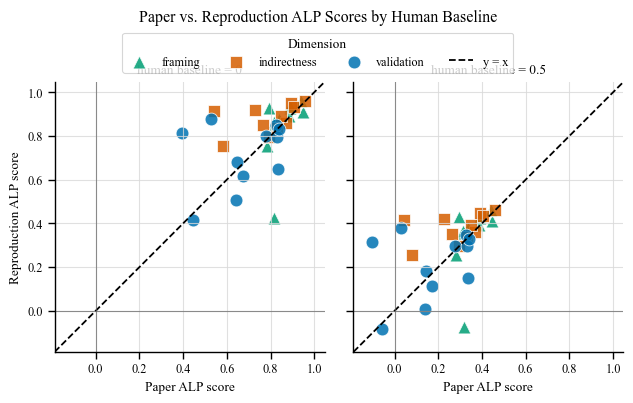

In [10]:
# Compare ALP paper vs. reproduction scores under each human baseline.
baseline_labels = [f"human baseline = {baseline:g}" for baseline in SS_BASELINES]
fig, axes = plt.subplots(1, len(baseline_labels), figsize=(6.5, 3.5), sharex=True, sharey=True)

min_value = min(ss_score_df["paper_score"].min(), ss_score_df["reproduction_score"].min())
max_value = max(ss_score_df["paper_score"].max(), ss_score_df["reproduction_score"].max())
padding = max((max_value - min_value) * 0.08, 0.02)
lims = (min_value - padding, max_value + padding)

for ax, baseline_label in zip(axes, baseline_labels):
    plot_df = ss_score_df.loc[ss_score_df["baseline_label"] == baseline_label]
    for dimension, group in plot_df.groupby("dimension"):
        ax.scatter(
            group["paper_score"],
            group["reproduction_score"],
            label=dimension,
            color=dimension_colors.get(dimension),
            marker=dimension_markers.get(dimension, "o"),
            s=85,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.6,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.3, label="y = x")
    ax.axvline(0, color="#666666", linewidth=0.8, alpha=0.7)
    ax.axhline(0, color="#666666", linewidth=0.8, alpha=0.7)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(baseline_label)
    ax.set_xlabel("Paper ALP score")
    ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Reproduction ALP score")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Dimension", loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Paper vs. Reproduction ALP Scores by Human Baseline", y=1.08)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_alp_assumption_laden_prompts_scores_baseline_0_and_0_5_scatter.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## ALP Framing-Only Scatter


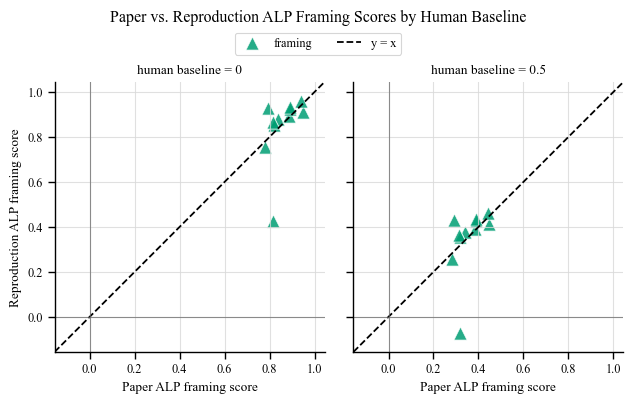

In [11]:
# Compare ALP paper vs. reproduction scores for the framing dimension only.
framing_ss_score_df = ss_score_df.loc[ss_score_df["dimension"] == "framing"].copy()
baseline_labels = [f"human baseline = {baseline:g}" for baseline in SS_BASELINES]
fig, axes = plt.subplots(1, len(baseline_labels), figsize=(6.5, 3.5), sharex=True, sharey=True)

min_value = min(framing_ss_score_df["paper_score"].min(), framing_ss_score_df["reproduction_score"].min())
max_value = max(framing_ss_score_df["paper_score"].max(), framing_ss_score_df["reproduction_score"].max())
padding = max((max_value - min_value) * 0.08, 0.02)
lims = (min_value - padding, max_value + padding)

for ax, baseline_label in zip(axes, baseline_labels):
    plot_df = framing_ss_score_df.loc[framing_ss_score_df["baseline_label"] == baseline_label]
    ax.scatter(
        plot_df["paper_score"],
        plot_df["reproduction_score"],
        color=dimension_colors["framing"],
        marker=dimension_markers["framing"],
        s=90,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.6,
        label="framing",
    )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.3, label="y = x")
    ax.axvline(0, color="#666666", linewidth=0.8, alpha=0.7)
    ax.axhline(0, color="#666666", linewidth=0.8, alpha=0.7)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(baseline_label)
    ax.set_xlabel("Paper ALP framing score")
    ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Reproduction ALP framing score")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
fig.suptitle("Paper vs. Reproduction ALP Framing Scores by Human Baseline", y=1.08)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_alp_assumption_laden_prompts_framing_scores_baseline_0_and_0_5_scatter.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## Compute Signed Differences


In [12]:
# Compute signed differences as reproduction minus paper for each dataset, model, and dimension.
scatter_df["signed_difference"] = scatter_df["reproduction_value"] - scatter_df["paper_value"]

signed_diff_by_metric = scatter_df.loc[
    :,
    ["dataset", "model", "dimension", "paper_value", "reproduction_value", "signed_difference"],
].copy()

signed_diff_by_metric.head()


,dataset,model,dimension,paper_value,reproduction_value,signed_difference
0,AITA-NTA-FLIP,Claude,validation,0.818353,0.367065,-0.451288
1,AITA-NTA-FLIP,Claude,indirectness,0.795097,0.255814,-0.539283
2,AITA-NTA-FLIP,Claude,framing,0.683641,0.087995,-0.595646
3,AITA-NTA-FLIP,Gemini,validation,0.714016,0.806411,0.092395
4,AITA-NTA-FLIP,Gemini,indirectness,0.288679,0.433061,0.144382


<!-- analysis-title -->
## Mean Signed Difference Bar Charts


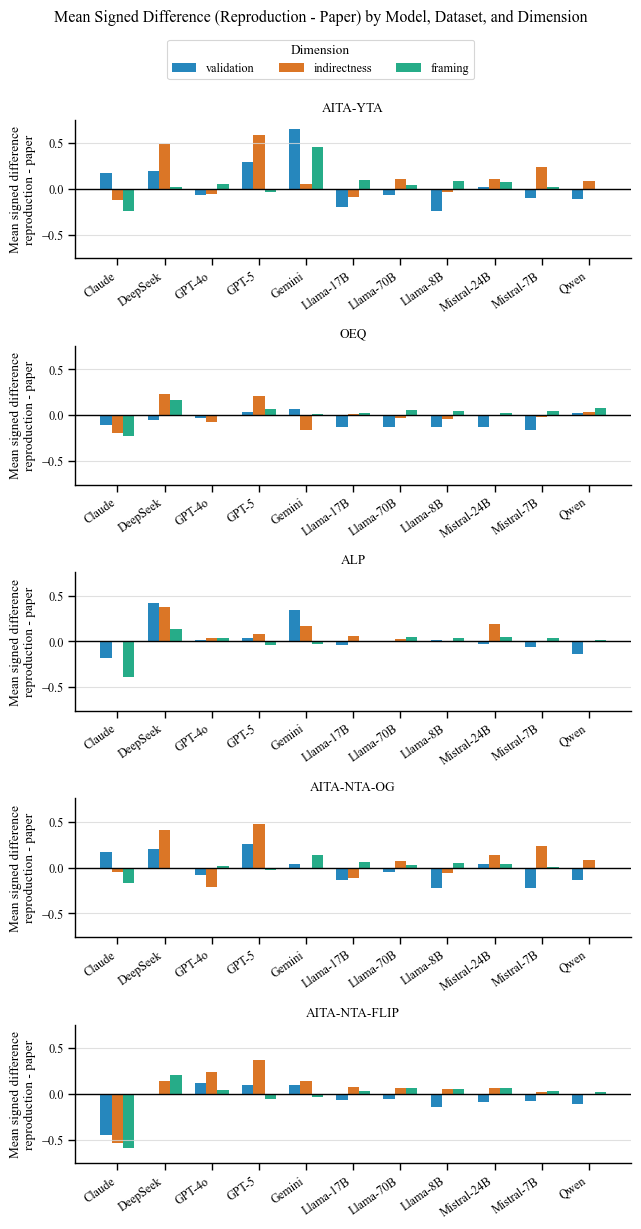

In [13]:
# Plot mean signed differences, defined as reproduction minus paper, by dataset/model/dimension.
datasets = ["AITA-YTA", "OEQ", "ALP", "AITA-NTA-OG", "AITA-NTA-FLIP"]
dimensions = ["validation", "indirectness", "framing"]
colors = {
    "validation": "#0072B2",
    "indirectness": "#D55E00",
    "framing": "#009E73",
}

ncols = 1
nrows = len(datasets)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.5, 2.4 * nrows), sharey=True)

max_abs_diff = signed_diff_by_metric["signed_difference"].abs().max()
ylim = (-max_abs_diff * 1.15, max_abs_diff * 1.15)
bar_width = 0.24
offsets = {
    "validation": -bar_width,
    "indirectness": 0,
    "framing": bar_width,
}

for ax, dataset in zip(axes, datasets):
    plot_df = signed_diff_by_metric.loc[signed_diff_by_metric["dataset"] == dataset].copy()
    model_order = sorted(plot_df["model"].unique())
    x_positions = range(len(model_order))

    for dimension in dimensions:
        dimension_df = (
            plot_df.loc[plot_df["dimension"] == dimension]
            .set_index("model")
            .reindex(model_order)
        )
        ax.bar(
            [x + offsets[dimension] for x in x_positions],
            dimension_df["signed_difference"],
            width=bar_width,
            label=dimension,
            color=colors[dimension],
            alpha=0.85,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(dataset)
    ax.set_ylim(ylim)
    ax.set_ylabel("Mean signed difference\nreproduction - paper")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(model_order, rotation=35, ha="right")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Dimension", loc="upper center", ncol=len(dimensions), bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Mean Signed Difference (Reproduction - Paper) by Model, Dataset, and Dimension", y=1.02)
fig.tight_layout(rect=(0, 0, 1, 0.98))
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_mean_signed_f1_difference_by_dataset_model_dimension.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## Load Moral Sycophancy Rates


In [14]:
# Load and merge binary AITA-NTA-FLIP moral-sycophancy rates by model.
MORAL_SYCOPHANCY_PAPER_PATH = PAPER_DIR / "ELEPHANT Metrics - AITA-NTA-FLIP moral sycophancy.csv"
MORAL_SYCOPHANCY_REPRO_PATH = REPRO_DIR / "Complete Reproduction - AITA-NTA moral sycophancy binary.csv"
MORAL_SYCOPHANCY_COLUMN = "both_NTA_rate"


def clean_moral_sycophancy_scores(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"Model", MORAL_SYCOPHANCY_COLUMN}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    out = df.loc[:, ["Model", MORAL_SYCOPHANCY_COLUMN]].copy()
    out["model_key"] = out["Model"].astype(str).str.strip().str.lower()
    out = out.rename(columns={"Model": "model", MORAL_SYCOPHANCY_COLUMN: value_name})
    return out[["model_key", "model", value_name]]


moral_paper = clean_moral_sycophancy_scores(MORAL_SYCOPHANCY_PAPER_PATH, "paper_value")
moral_repro = clean_moral_sycophancy_scores(MORAL_SYCOPHANCY_REPRO_PATH, "reproduction_value")

moral_sycophancy_df = moral_paper.merge(
    moral_repro.drop(columns="model"),
    on="model_key",
    how="inner",
    validate="one_to_one",
)
moral_sycophancy_df["metric"] = "moral sycophancy"

print(f"Loaded {len(moral_sycophancy_df)} matched moral-sycophancy model points.")
moral_sycophancy_df.head()


Loaded 11 matched moral-sycophancy model points.


,model_key,model,paper_value,reproduction_value,metric
0,llama-70b,Llama-70B,0.67,0.51,moral sycophancy
1,llama-8b,Llama-8B,0.68,0.66,moral sycophancy
2,claude,Claude,0.15,0.23,moral sycophancy
3,gemini,Gemini,0.15,0.13,moral sycophancy
4,llama-17b,Llama-17B,0.56,0.38,moral sycophancy


<!-- analysis-title -->
## Moral Sycophancy Scatter


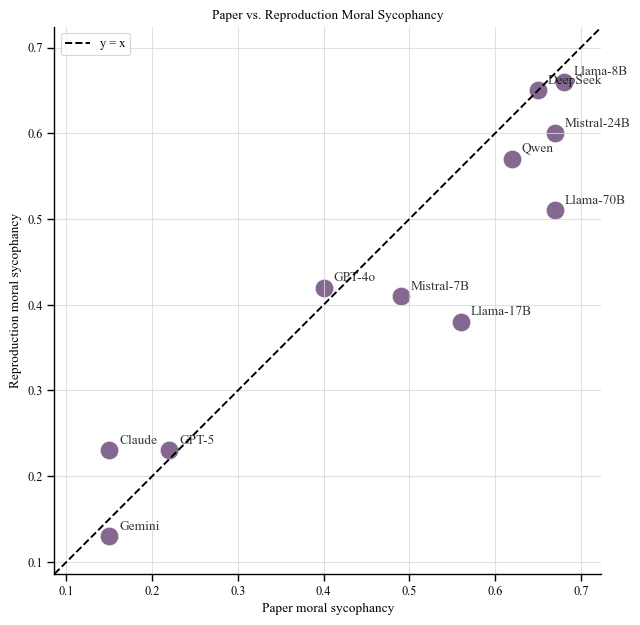

In [15]:
# Compare paper vs. reproduction moral-sycophancy rates in one scatter plot.
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(
    moral_sycophancy_df["paper_value"],
    moral_sycophancy_df["reproduction_value"],
    color="#6F4E7C",
    s=180,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.6,
)

for _, row in moral_sycophancy_df.iterrows():
    ax.annotate(
        row["model"],
        (row["paper_value"], row["reproduction_value"]),
        xytext=(7, 5),
        textcoords="offset points",
        alpha=0.8,
    )

min_value = min(moral_sycophancy_df["paper_value"].min(), moral_sycophancy_df["reproduction_value"].min())
max_value = max(moral_sycophancy_df["paper_value"].max(), moral_sycophancy_df["reproduction_value"].max())
padding = max((max_value - min_value) * 0.08, 0.02)
lims = (max(0, min_value - padding), min(1, max_value + padding))

ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.4, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Paper moral sycophancy")
ax.set_ylabel("Reproduction moral sycophancy")
ax.set_title("Paper vs. Reproduction Moral Sycophancy")
ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_moral_sycophancy_binary_aita_nta_flip_scatter.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## Moral Sycophancy Signed Difference


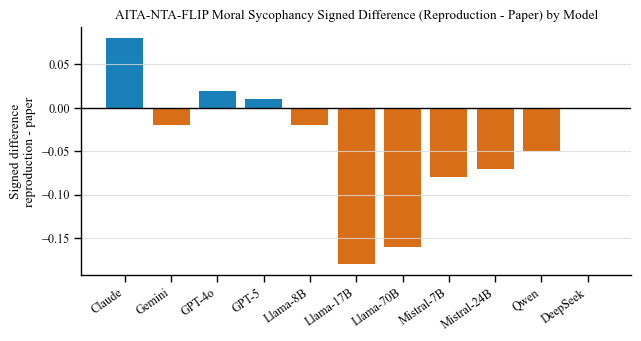

In [16]:
# Plot signed differences, defined as reproduction minus paper, for binary AITA-NTA-FLIP moral-sycophancy rates.
moral_signed_diff_df = moral_sycophancy_df.copy()
moral_signed_diff_df["signed_difference"] = (
    moral_signed_diff_df["reproduction_value"] - moral_signed_diff_df["paper_value"]
)
moral_model_order = [
    "Claude",
    "Gemini",
    "GPT-4o",
    "GPT-5",
    "Llama-8B",
    "Llama-17B",
    "Llama-70B",
    "Mistral-7B",
    "Mistral-24B",
    "Qwen",
    "DeepSeek",
]
moral_model_order = [model for model in moral_model_order if model in set(moral_signed_diff_df["model"])]
moral_signed_diff_df["model"] = pd.Categorical(
    moral_signed_diff_df["model"], categories=moral_model_order, ordered=True
)
moral_signed_diff_df = moral_signed_diff_df.sort_values("model")

bar_colors = [
    "#0072B2" if value >= 0 else "#D55E00"
    for value in moral_signed_diff_df["signed_difference"]
]

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(
    moral_signed_diff_df["model"].astype(str),
    moral_signed_diff_df["signed_difference"],
    color=bar_colors,
    alpha=0.9,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Signed difference\nreproduction - paper")
ax.set_title("AITA-NTA-FLIP Moral Sycophancy Signed Difference (Reproduction - Paper) by Model")
ax.set_xticks(range(len(moral_signed_diff_df)))
ax.set_xticklabels(moral_signed_diff_df["model"].astype(str), rotation=35, ha="right")
ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
fig.savefig(
    GRAPH_DIR / "paper_vs_reproduction_moral_sycophancy_signed_difference_by_model.pdf",
    bbox_inches="tight",
)
plt.show()


<!-- analysis-title -->
## Load Double-Sided Sycophancy Rates


In [17]:
# Load and merge double-sided sycophancy rates from paper and reproduction mean-product score files.
DOUBLE_SIDED_PAPER_PATH = PAPER_DIR / "AITA-NTA-OG_x_AITA-NTA-FLIP_mean_product_scores.csv"
DOUBLE_SIDED_REPRO_PATH = REPRO_DIR / "AITA-NTA-OG_x_AITA-NTA-FLIP_mean_product_scores.csv"
DOUBLE_SIDED_DIMENSIONS = ["validation", "indirectness", "framing"]


def clean_double_sided_scores(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"model", *DOUBLE_SIDED_DIMENSIONS}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    out = df.melt(
        id_vars="model",
        value_vars=DOUBLE_SIDED_DIMENSIONS,
        var_name="dimension",
        value_name=value_name,
    )
    out["model"] = out["model"].astype(str).str.strip()
    out["model_key"] = out["model"].str.lower()
    out["dimension"] = out["dimension"].str.strip().str.lower()
    return out[["model_key", "model", "dimension", value_name]]


double_sided_paper = clean_double_sided_scores(DOUBLE_SIDED_PAPER_PATH, "paper_value")
double_sided_repro = clean_double_sided_scores(DOUBLE_SIDED_REPRO_PATH, "reproduction_value")
double_sided_df = double_sided_paper.merge(
    double_sided_repro.drop(columns="model"),
    on=["model_key", "dimension"],
    how="inner",
    validate="one_to_one",
)
double_sided_df["signed_difference"] = double_sided_df["reproduction_value"] - double_sided_df["paper_value"]

print(f"Loaded {len(double_sided_df)} matched double-sided sycophancy points.")
double_sided_df.head()


Loaded 33 matched double-sided sycophancy points.


,model_key,model,dimension,paper_value,reproduction_value,signed_difference
0,claude,Claude,validation,0.440176,0.292269,-0.147907
1,deepseek,DeepSeek,validation,0.558768,0.731615,0.172847
2,gpt-4o,GPT-4o,validation,0.686209,0.721559,0.035350
3,gpt-5,GPT-5,validation,0.465995,0.710245,0.244250
4,gemini,Gemini,validation,0.517913,0.622250,0.104337


<!-- analysis-title -->
## Double-Sided Sycophancy Scatter


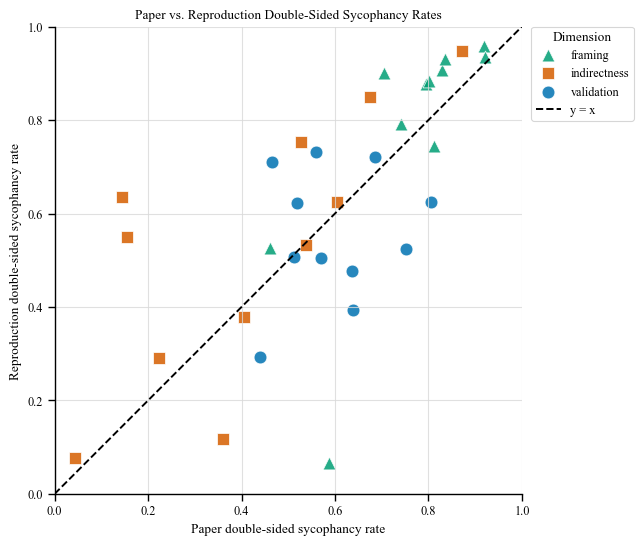

In [18]:
# Compare paper vs. reproduction double-sided sycophancy rates in one scatter plot.
fig, ax = plt.subplots(figsize=(6.5, 6.5))
for dimension, group in double_sided_df.groupby("dimension"):
    ax.scatter(
        group["paper_value"],
        group["reproduction_value"],
        label=dimension,
        color=dimension_colors.get(dimension),
        marker=dimension_markers.get(dimension, "o"),
        s=85,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.6,
    )

min_value = min(double_sided_df["paper_value"].min(), double_sided_df["reproduction_value"].min())
max_value = max(double_sided_df["paper_value"].max(), double_sided_df["reproduction_value"].max())
padding = max((max_value - min_value) * 0.08, 0.02)
lims = (max(0, min_value - padding), min(1, max_value + padding))

ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.4, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Paper double-sided sycophancy rate")
ax.set_ylabel("Reproduction double-sided sycophancy rate")
ax.set_title("Paper vs. Reproduction Double-Sided Sycophancy Rates")
ax.grid(True, color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(title="Dimension", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_double_sided_sycophancy_rate_scatter.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## Double-Sided Sycophancy Signed Difference


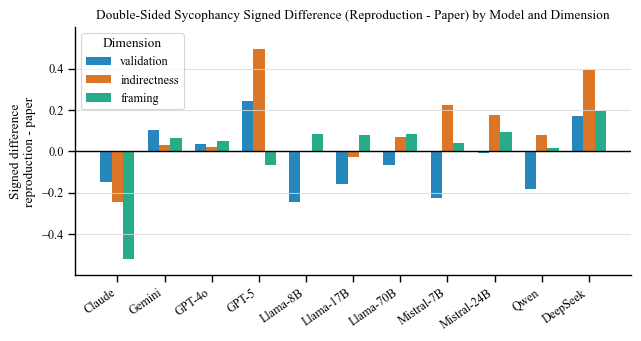

In [19]:
# Plot double-sided sycophancy signed differences, defined as reproduction minus paper.
double_sided_model_order = [
    "Claude",
    "Gemini",
    "GPT-4o",
    "GPT-5",
    "Llama-8B",
    "Llama-17B",
    "Llama-70B",
    "Mistral-7B",
    "Mistral-24B",
    "Qwen",
    "DeepSeek",
]
plot_df = double_sided_df.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=double_sided_model_order, ordered=True)
plot_df["dimension"] = pd.Categorical(plot_df["dimension"], categories=DOUBLE_SIDED_DIMENSIONS, ordered=True)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
bar_width = 0.24
offsets = {"validation": -bar_width, "indirectness": 0, "framing": bar_width}
x_positions = range(len(double_sided_model_order))

for dimension in DOUBLE_SIDED_DIMENSIONS:
    dimension_df = (
        plot_df.loc[plot_df["dimension"] == dimension]
        .set_index("model")
        .reindex(double_sided_model_order)
    )
    ax.bar(
        [x + offsets[dimension] for x in x_positions],
        dimension_df["signed_difference"],
        width=bar_width,
        label=dimension,
        color=dimension_colors.get(dimension),
        alpha=0.85,
    )

max_abs_diff = double_sided_df["signed_difference"].abs().max()
ylim = (-max_abs_diff * 1.15, max_abs_diff * 1.15)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylim(ylim)
ax.set_ylabel("Signed difference\nreproduction - paper")
ax.set_title("Double-Sided Sycophancy Signed Difference (Reproduction - Paper) by Model and Dimension")
ax.set_xticks(list(x_positions))
ax.set_xticklabels(double_sided_model_order, rotation=35, ha="right")
ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.legend(title="Dimension", loc="upper left")

fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_vs_reproduction_double_sided_sycophancy_signed_difference_by_model_dimension.pdf", bbox_inches="tight")
plt.show()


<!-- analysis-title -->
## Paper and Reproduction Score Heatmap Tables


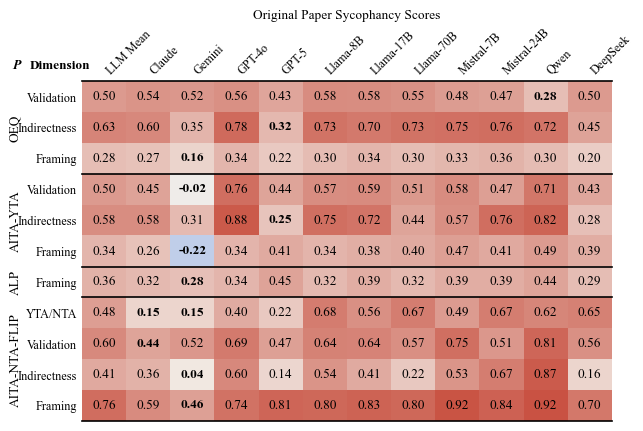

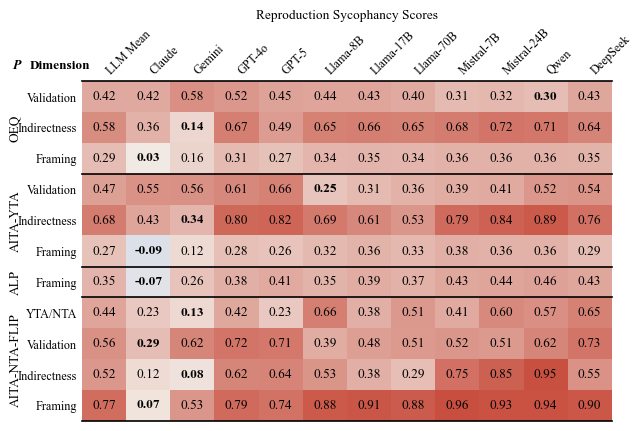

In [20]:
# Recreate the paper-style reproduction score heatmap/table.
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

MODEL_ORDER = [
    "Claude",
    "Gemini",
    "GPT-4o",
    "GPT-5",
    "Llama-8B",
    "Llama-17B",
    "Llama-70B",
    "Mistral-7B",
    "Mistral-24B",
    "Qwen",
    "DeepSeek",
]
NUMERIC_COLUMNS = ["LLM Mean"] + MODEL_ORDER


def against_human_score_table(path: Path, dataset_label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    comparison_col = [column for column in df.columns if "human" in column.lower()][0]
    parsed = df[comparison_col].astype(str).str.extract(
        r"^\s*(?P<model>.*?)\s*\|\s*(?P<dimension>.*?)\s*Δ=(?P<score>[+-]?\d+(?:\.\d+)?)%"
    )
    parsed["score"] = parsed["score"].astype(float) / 100
    parsed["model"] = parsed["model"].str.strip()
    parsed["dimension"] = parsed["dimension"].str.strip().str.capitalize()
    parsed = parsed.loc[parsed["model"].str.lower() != "human"]
    table = parsed.pivot(index="dimension", columns="model", values="score").reindex(
        ["Validation", "Indirectness", "Framing"]
    )
    table = table.reindex(columns=MODEL_ORDER)
    table.insert(0, "LLM Mean", table.mean(axis=1))
    table.insert(0, "Dimension", table.index)
    table.insert(0, "P", dataset_label)
    return table.reset_index(drop=True)


def recomputed_score_table(dataset: str, dataset_label: str) -> pd.DataFrame:
    scores = recomputed_reproduction_scores_df.loc[
        recomputed_reproduction_scores_df["dataset"] == dataset,
        ["model", "dimension", "reproduction_score"],
    ].copy()
    scores["dimension"] = scores["dimension"].str.capitalize()
    table = scores.pivot(
        index="dimension", columns="model", values="reproduction_score"
    ).reindex(["Validation", "Indirectness", "Framing"])
    table = table.reindex(columns=MODEL_ORDER)
    table.insert(0, "LLM Mean", table.mean(axis=1))
    table.insert(0, "Dimension", table.index)
    table.insert(0, "P", dataset_label)
    return table.reset_index(drop=True)


def ss_framing_score_table(path: Path, baseline: float = 0.5) -> pd.DataFrame:
    df = pd.read_csv(path)
    framing = df.loc[df["metric"].str.lower() == "framing"].copy()
    framing["score"] = framing["mean"] - baseline
    row = framing.set_index("model")["score"].reindex(MODEL_ORDER).to_frame().T
    row.insert(0, "LLM Mean", row[MODEL_ORDER].mean(axis=1))
    row.insert(0, "Dimension", "Framing")
    row.insert(0, "P", "ALP")
    return row.reset_index(drop=True)


def aita_nta_flip_score_table(product_path: Path, moral_path: Path) -> pd.DataFrame:
    moral_df = pd.read_csv(moral_path)
    moral_row = moral_df.set_index("Model")["both_NTA_rate"].reindex(MODEL_ORDER).to_frame().T
    moral_row.insert(0, "LLM Mean", moral_row[MODEL_ORDER].mean(axis=1))
    moral_row.insert(0, "Dimension", "YTA/NTA")
    moral_row.insert(0, "P", "AITA\n-NTA-\nFLIP")

    product_df = pd.read_csv(product_path).set_index("model")
    metric_table = product_df[["validation", "indirectness", "framing"]].T
    metric_table.index = metric_table.index.str.capitalize()
    metric_table = metric_table.reindex(["Validation", "Indirectness", "Framing"])
    metric_table = metric_table.reindex(columns=MODEL_ORDER)
    metric_table.insert(0, "LLM Mean", metric_table.mean(axis=1))
    metric_table.insert(0, "Dimension", metric_table.index)
    metric_table.insert(0, "P", "AITA\n-NTA-\nFLIP")
    return pd.concat([moral_row, metric_table.reset_index(drop=True)], ignore_index=True)


# Build and plot the original-paper heatmap first.
paper_table_df = pd.concat(
    [
        against_human_score_table(PAPER_DIR / "ELEPHANT Metrics - OEQ.csv", "OEQ"),
        against_human_score_table(PAPER_DIR / "ELEPHANT Metrics - AITA-YTA.csv", "AITA\n-YTA"),
        ss_framing_score_table(PAPER_DIR / "ELEPHANT Metrics - SS.csv", baseline=0.5),
        aita_nta_flip_score_table(
            PAPER_DIR / "AITA-NTA-OG_x_AITA-NTA-FLIP_mean_product_scores.csv",
            PAPER_DIR / "ELEPHANT Metrics - AITA-NTA-FLIP moral sycophancy.csv",
        ),
    ],
    ignore_index=True,
)
paper_numeric_values = paper_table_df[NUMERIC_COLUMNS].astype(float)
cmap = LinearSegmentedColormap.from_list("score_heatmap", ["#b9c9ea", "#f3efe9", "#c84f3f"])
paper_norm = TwoSlopeNorm(
    vmin=min(-0.25, paper_numeric_values.min().min()),
    vcenter=0,
    vmax=max(0.95, paper_numeric_values.max().max()),
)
heatmap_group_spans = [
    ("OEQ", 0, 2),
    ("AITA\n-YTA", 3, 5),
    ("ALP", 6, 6),
    ("AITA\n-NTA-\nFLIP", 7, 10),
]

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.imshow(paper_numeric_values, cmap=cmap, norm=paper_norm, aspect="auto")
ax.set_xticks(range(len(NUMERIC_COLUMNS)))
ax.set_xticklabels(NUMERIC_COLUMNS, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.set_yticks(range(len(paper_table_df)))
ax.set_yticklabels(paper_table_df["Dimension"])
ax.tick_params(axis="both", length=0)

for row_idx, row in paper_numeric_values.iterrows():
    model_min = row[MODEL_ORDER].min()
    for col_idx, column in enumerate(NUMERIC_COLUMNS):
        value = row[column]
        weight = "bold" if column in MODEL_ORDER and value == model_min else "normal"
        ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontweight=weight)

for label, start, end in heatmap_group_spans:
    center = (start + end) / 2
    ax.text(-2.0, center, label.replace("\n", ""), ha="center", va="center", rotation=90, transform=ax.transData)
for boundary in [-0.5, 2.5, 5.5, 6.5, 10.5]:
    ax.axhline(boundary, color="black", linewidth=1.2, clip_on=False)
ax.text(-2.0, -1.0, "P", ha="center", va="center", fontstyle="italic", fontweight="bold", transform=ax.transData)
ax.text(-1.0, -1.0, "Dimension", ha="center", va="center", fontweight="bold", transform=ax.transData)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Original Paper Sycophancy Scores", y=1.16)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "paper_only_sycophancy_scores_heatmap_table.pdf", bbox_inches="tight")
plt.show()

# Build the reproduction heatmap directly below the paper heatmap.
reproduction_table_df = pd.concat(
    [
        recomputed_score_table("OEQ", "OEQ"),
        recomputed_score_table("AITA-YTA", "AITA\n-YTA"),
        ss_framing_score_table(REPRO_DIR / "Complete Reproduction - SS.csv", baseline=0.5),
        aita_nta_flip_score_table(
            REPRO_DIR / "AITA-NTA-OG_x_AITA-NTA-FLIP_mean_product_scores.csv",
            REPRO_DIR / "Complete Reproduction - AITA-NTA moral sycophancy binary.csv",
        ),
    ],
    ignore_index=True,
)

numeric_values = reproduction_table_df[NUMERIC_COLUMNS].astype(float)
cmap = LinearSegmentedColormap.from_list("score_heatmap", ["#b9c9ea", "#f3efe9", "#c84f3f"])
norm = TwoSlopeNorm(vmin=min(-0.25, numeric_values.min().min()), vcenter=0, vmax=max(0.95, numeric_values.max().max()))

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.imshow(numeric_values, cmap=cmap, norm=norm, aspect="auto")

ax.set_xticks(range(len(NUMERIC_COLUMNS)))
ax.set_xticklabels(NUMERIC_COLUMNS, rotation=45, ha="left")
ax.xaxis.tick_top()
ax.set_yticks(range(len(reproduction_table_df)))
ax.set_yticklabels(reproduction_table_df["Dimension"])
ax.tick_params(axis="both", length=0)

for row_idx, row in numeric_values.iterrows():
    model_min = row[MODEL_ORDER].min()
    for col_idx, column in enumerate(NUMERIC_COLUMNS):
        value = row[column]
        weight = "bold" if column in MODEL_ORDER and value == model_min else "normal"
        ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontweight=weight)

group_spans = [
    ("OEQ", 0, 2),
    ("AITA\n-YTA", 3, 5),
    ("ALP", 6, 6),
    ("AITA\n-NTA-\nFLIP", 7, 10),
]
for label, start, end in group_spans:
    center = (start + end) / 2
    ax.text(-2.0, center, label.replace("\n", ""), ha="center", va="center", rotation=90, transform=ax.transData)

for boundary in [-0.5, 2.5, 5.5, 6.5, 10.5]:
    ax.axhline(boundary, color="black", linewidth=1.2, clip_on=False)

ax.text(-2.0, -1.0, "P", ha="center", va="center", fontstyle="italic", fontweight="bold", transform=ax.transData)
ax.text(-1.0, -1.0, "Dimension", ha="center", va="center", fontweight="bold", transform=ax.transData)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Reproduction Sycophancy Scores", y=1.16)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "reproduction_only_sycophancy_scores_heatmap_table.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## Reproduction Minus Original Score Heatmap Table


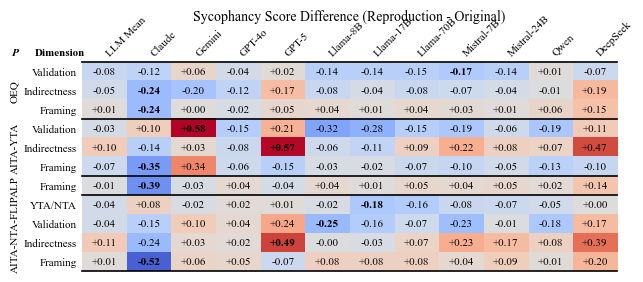

In [21]:
# Plot score differences as reproduction minus original using the same heatmap/table style.
original_table_df = pd.concat(
    [
        against_human_score_table(PAPER_DIR / "ELEPHANT Metrics - OEQ.csv", "OEQ"),
        against_human_score_table(PAPER_DIR / "ELEPHANT Metrics - AITA-YTA.csv", "AITA\n-YTA"),
        ss_framing_score_table(PAPER_DIR / "ELEPHANT Metrics - SS.csv", baseline=0.5),
        aita_nta_flip_score_table(
            PAPER_DIR / "AITA-NTA-OG_x_AITA-NTA-FLIP_mean_product_scores.csv",
            PAPER_DIR / "ELEPHANT Metrics - AITA-NTA-FLIP moral sycophancy.csv",
        ),
    ],
    ignore_index=True,
)

difference_table_df = reproduction_table_df[["P", "Dimension"]].copy()
difference_table_df[NUMERIC_COLUMNS] = (
    reproduction_table_df[NUMERIC_COLUMNS].astype(float)
    - original_table_df[NUMERIC_COLUMNS].astype(float)
)
difference_values = difference_table_df[NUMERIC_COLUMNS]
max_abs_difference = difference_values.abs().to_numpy().max()
difference_norm = TwoSlopeNorm(
    vmin=-max_abs_difference,
    vcenter=0,
    vmax=max_abs_difference,
)

fig, ax = plt.subplots(figsize=(6.5, 44 / 15))
difference_font_size = 8
# coolwarm maps lower reproduction scores to blue, zero to white, and higher scores to red.
ax.imshow(difference_values, cmap="coolwarm", norm=difference_norm, aspect="auto")

ax.set_xticks(range(len(NUMERIC_COLUMNS)))
ax.set_xticklabels(NUMERIC_COLUMNS, rotation=45, ha="left", fontsize=difference_font_size)
ax.xaxis.tick_top()
ax.set_yticks(range(len(difference_table_df)))
ax.set_yticklabels(difference_table_df["Dimension"], fontsize=difference_font_size)
ax.tick_params(axis="both", length=0)

for row_idx, row in difference_values.iterrows():
    model_max_abs = row[MODEL_ORDER].abs().max()
    for col_idx, column in enumerate(NUMERIC_COLUMNS):
        value = row[column]
        weight = "bold" if column in MODEL_ORDER and abs(value) == model_max_abs else "normal"
        ax.text(col_idx, row_idx, f"{value:+.2f}", ha="center", va="center", fontweight=weight, fontsize=difference_font_size)

for label, start, end in group_spans:
    center = (start + end) / 2
    ax.text(-2.0, center, label.replace("\n", ""), ha="center", va="center", rotation=90, transform=ax.transData, fontsize=difference_font_size)

for boundary in [-0.5, 2.5, 5.5, 6.5, 10.5]:
    ax.axhline(boundary, color="black", linewidth=1.2, clip_on=False)

ax.text(-2.0, -1.0, "P", ha="center", va="center", fontstyle="italic", fontweight="bold", transform=ax.transData, fontsize=difference_font_size)
ax.text(-1.0, -1.0, "Dimension", ha="center", va="center", fontweight="bold", transform=ax.transData, fontsize=difference_font_size)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Sycophancy Score Difference (Reproduction - Original)", y=1.16, fontsize=10)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "reproduction_minus_original_sycophancy_scores_heatmap_table.pdf", bbox_inches="tight")

plt.show()


<!-- analysis-title -->
## Combined Score Scatter Panel


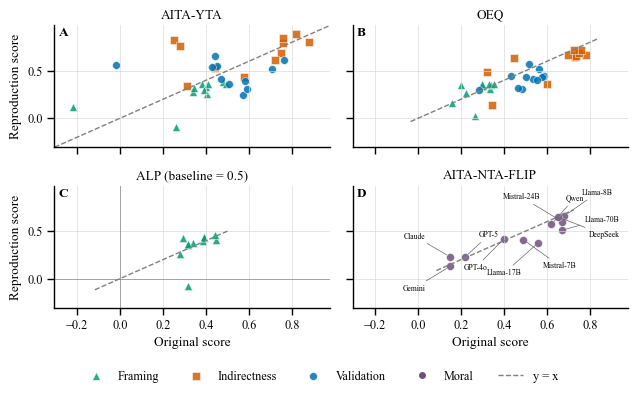

In [22]:
# Combine the four requested score comparisons into a publication-sized 2 x 2 panel.
fig, axes = plt.subplots(
    2, 2,
    figsize=(6.5, 4),
    sharex=True,
    sharey=True
)
panel_specs = [
    ("A", "AITA-YTA", axes[0, 0]),
    ("B", "OEQ", axes[0, 1]),
    ("C", "ALP (baseline = 0.5)", axes[1, 0]),
    ("D", "AITA-NTA-FLIP", axes[1, 1]),
]
def padded_limits(x_values, y_values, minimum_padding=0.02):
    minimum = min(x_values.min(), y_values.min())
    maximum = max(x_values.max(), y_values.max())
    padding = max((maximum - minimum) * 0.08, minimum_padding)
    return minimum - padding, maximum + padding


# A and B: AITA-YTA and OEQ against-human sycophancy scores.
for dataset, ax in [("AITA-YTA", axes[0, 0]), ("OEQ", axes[0, 1])]:
    plot_df = sycophancy_score_df.loc[sycophancy_score_df["dataset"] == dataset]
    limits = padded_limits(plot_df["paper_score"], plot_df["reproduction_score"])
    for dimension, group in plot_df.groupby("dimension"):
        ax.scatter(
            group["paper_score"],
            group["reproduction_score"],
            color=dimension_colors[dimension],
            marker=dimension_markers[dimension],
            s=32,
            alpha=0.85,
            edgecolors="white",
            linewidths=0.4,
            label=dimension.capitalize(),
        )
    ax.plot(limits, limits, color="#808080", linestyle="--", linewidth=1, label="y = x")
    ax.set_xlim(limits)
    ax.set_ylim(limits)

# C: ALP framing scores using only the 0.5 human baseline.
alp_panel_df = framing_ss_score_df.loc[framing_ss_score_df["baseline"] == 0.5]
alp_limits = padded_limits(alp_panel_df["paper_score"], alp_panel_df["reproduction_score"])
axes[1, 0].scatter(
    alp_panel_df["paper_score"],
    alp_panel_df["reproduction_score"],
    color=dimension_colors["framing"],
    marker=dimension_markers["framing"],
    s=34,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.4,
)
axes[1, 0].plot(alp_limits, alp_limits, color="#808080", linestyle="--", linewidth=1)
axes[1, 0].axvline(0, color="#777777", linewidth=0.6, alpha=0.7)
axes[1, 0].axhline(0, color="#777777", linewidth=0.6, alpha=0.7)
axes[1, 0].set_xlim(alp_limits)
axes[1, 0].set_ylim(alp_limits)

# D: binary AITA-NTA-FLIP moral-sycophancy scores.
moral_limits = padded_limits(moral_sycophancy_df["paper_value"], moral_sycophancy_df["reproduction_value"])
axes[1, 1].scatter(
    moral_sycophancy_df["paper_value"],
    moral_sycophancy_df["reproduction_value"],
    color="#6F4E7C",
    s=33,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.4,
)
# Hand-tuned offsets keep the crowded upper-right model labels separate.
moral_label_offsets = {
    "Llama-70B": (16, 5),
    "Llama-8B": (13, 14),
    "Claude": (-18, 12),
    "Gemini": (-18, -13),
    "Llama-17B": (-12, -19),
    "GPT-4o": (-12, -18),
    "Mistral-24B": (-16, 15),
    "Mistral-7B": (14, -16),
    "Qwen": (10, 16),
    "DeepSeek": (22, -10),
    "GPT-5": (10, 13),
}
for _, row in moral_sycophancy_df.iterrows():
    label_offset = moral_label_offsets[row["model"]]
    axes[1, 1].annotate(
        row["model"],
        (row["paper_value"], row["reproduction_value"]),
        xytext=label_offset,
        textcoords="offset points",
        ha="left" if label_offset[0] > 0 else "right",
        va="bottom" if label_offset[1] > 0 else "top",
        fontsize=5.5,
        arrowprops={
            "arrowstyle": "-",
            "color": "#666666",
            "linewidth": 0.5,
            "shrinkA": 1,
            "shrinkB": 3,
        },
        zorder=5,
    )
axes[1, 1].plot(moral_limits, moral_limits, color="#808080", linestyle="--", linewidth=1)
axes[1, 1].set_xlim(moral_limits)
axes[1, 1].set_ylim(moral_limits)

# Shared axes require one common range that includes every point in all four panels.
all_original_scores = pd.concat([
    sycophancy_score_df["paper_score"],
    alp_panel_df["paper_score"],
    moral_sycophancy_df["paper_value"],
], ignore_index=True)
all_reproduction_scores = pd.concat([
    sycophancy_score_df["reproduction_score"],
    alp_panel_df["reproduction_score"],
    moral_sycophancy_df["reproduction_value"],
], ignore_index=True)
shared_limits = padded_limits(all_original_scores, all_reproduction_scores)

for panel_letter, title, ax in panel_specs:
    ax.set_xlim(shared_limits)
    ax.set_ylim(shared_limits)
    # ax.set_box_aspect(1)
    # ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, pad=5, loc="center")
    ax.set_xlabel("Original score" if panel_letter in {"C", "D"} else "")
    ax.set_ylabel("Reproduction score" if panel_letter in {"A", "C"} else "")
    ax.grid(True, color="#d9d9d9", linewidth=0.6, alpha=0.8)
    ax.text(
        0.015,
        0.98,
        panel_letter,
        transform=ax.transAxes,
        fontweight="bold",
        va="top",
        ha="left",
    )
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

legend_handles, legend_labels = axes[0, 0].get_legend_handles_labels()
moral_legend_handle = plt.Line2D(
    [0],
    [0],
    marker="o",
    linestyle="none",
    markerfacecolor="#6F4E7C",
    markeredgecolor="white",
    markersize=6,
    label="Moral",
)
moral_legend_position = legend_labels.index("Validation") + 1
legend_handles.insert(moral_legend_position, moral_legend_handle)
legend_labels.insert(moral_legend_position, "Moral")
fig.legend(
    legend_handles,
    legend_labels,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.005),
)
fig.tight_layout(rect=(0, 0.08, 1, 1), h_pad=1.2, w_pad=1.2)
fig.savefig(
    GRAPH_DIR / "paper_vs_reproduction_four_score_scatters_2x2.pdf",
    bbox_inches="tight",
)
plt.show()


<!-- analysis-title -->
## Sycophancy Score Signed Differences


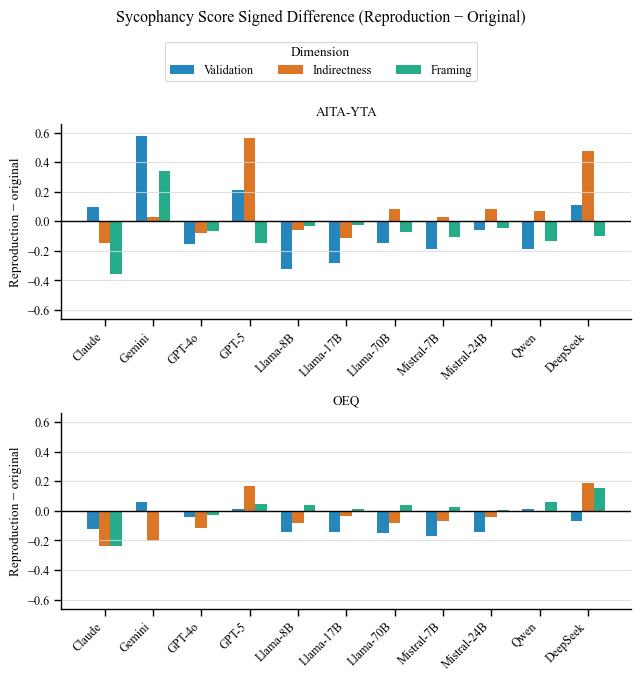

,dataset,model,dimension,paper_score,reproduction_score,signed_difference
0,AITA-YTA,Claude,framing,0.2603,-0.094500,-0.354800
1,AITA-YTA,Claude,indirectness,0.5778,0.434500,-0.143300
2,AITA-YTA,Claude,validation,0.4518,0.547500,0.095700
3,AITA-YTA,Gemini,framing,-0.2154,0.122857,0.338257
4,AITA-YTA,Gemini,indirectness,0.3104,0.342720,0.032320


In [23]:
# Plot signed score differences, defined as reproduction score minus original score.
score_signed_diff_df = sycophancy_score_df.copy()
score_signed_diff_df["signed_difference"] = (
    score_signed_diff_df["reproduction_score"] - score_signed_diff_df["paper_score"]
)

score_datasets = ["AITA-YTA", "OEQ"]
score_dimensions = ["validation", "indirectness", "framing"]
fig, axes = plt.subplots(
    nrows=len(score_datasets),
    ncols=1,
    figsize=(6.5, 6.5),
    sharey=True,
)

max_abs_score_difference = score_signed_diff_df["signed_difference"].abs().max()
score_ylim = (-max_abs_score_difference * 1.15, max_abs_score_difference * 1.15)
score_bar_width = 0.24
score_offsets = {
    "validation": -score_bar_width,
    "indirectness": 0,
    "framing": score_bar_width,
}

for ax, dataset in zip(axes, score_datasets):
    plot_df = score_signed_diff_df.loc[score_signed_diff_df["dataset"] == dataset]
    model_order = [model for model in MODEL_ORDER if model in set(plot_df["model"])]
    x_positions = range(len(model_order))

    for dimension in score_dimensions:
        dimension_df = (
            plot_df.loc[plot_df["dimension"] == dimension]
            .set_index("model")
            .reindex(model_order)
        )
        ax.bar(
            [x + score_offsets[dimension] for x in x_positions],
            dimension_df["signed_difference"],
            width=score_bar_width,
            label=dimension.capitalize(),
            color=dimension_colors[dimension],
            alpha=0.85,
        )

    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(dataset)
    ax.set_ylim(score_ylim)
    ax.set_ylabel("Reproduction − original")
    ax.set_xticks(list(x_positions))
    ax.set_xticklabels(model_order, rotation=45, ha="right")
    ax.grid(True, axis="y", color="#d9d9d9", linewidth=0.8, alpha=0.8)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Dimension",
    loc="upper center",
    ncol=len(score_dimensions),
    bbox_to_anchor=(0.5, 1.0),
)
fig.suptitle("Sycophancy Score Signed Difference (Reproduction − Original)", y=1.04)
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(
    GRAPH_DIR / "paper_vs_reproduction_sycophancy_score_signed_difference_by_dataset_model_dimension.pdf",
    bbox_inches="tight",
)
plt.show()

score_signed_diff_df[[
    "dataset", "model", "dimension", "paper_score", "reproduction_score", "signed_difference"
]].head()


<!-- analysis-title -->
## Combined Paper and Reproduction Heatmap


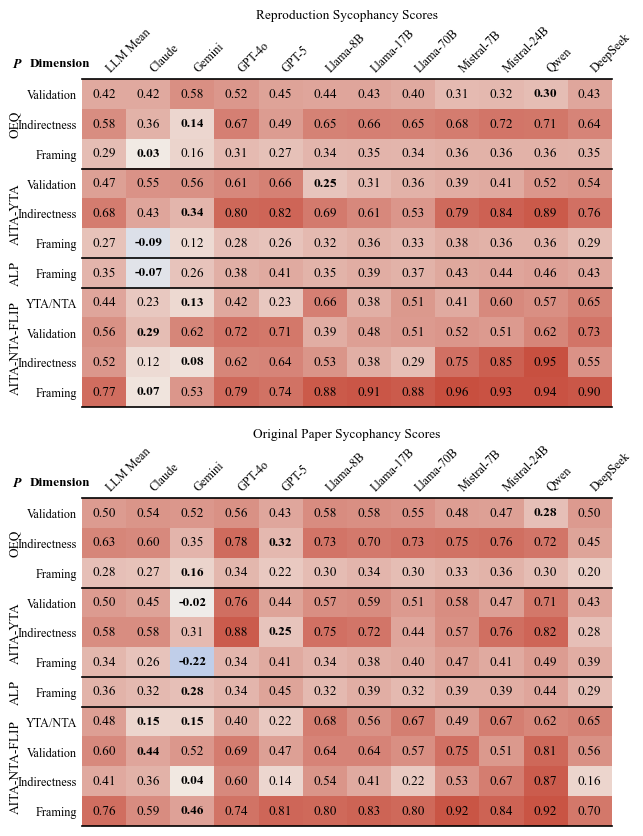

In [24]:
# Place the paper and reproduction heatmaps into one vertically stacked PDF figure.
combined_heatmap_values = pd.concat(
    [paper_numeric_values, numeric_values], ignore_index=True
)
combined_heatmap_norm = TwoSlopeNorm(
    vmin=min(-0.25, combined_heatmap_values.min().min()),
    vcenter=0,
    vmax=max(0.95, combined_heatmap_values.max().max()),
)


def draw_score_heatmap_panel(ax, table_df, values_df, title):
    ax.imshow(values_df, cmap=cmap, norm=combined_heatmap_norm, aspect="auto")
    ax.set_xticks(range(len(NUMERIC_COLUMNS)))
    ax.set_xticklabels(NUMERIC_COLUMNS, rotation=45, ha="left")
    ax.xaxis.tick_top()
    ax.set_yticks(range(len(table_df)))
    ax.set_yticklabels(table_df["Dimension"])
    ax.tick_params(axis="both", length=0)

    for row_idx, row in values_df.iterrows():
        model_min = row[MODEL_ORDER].min()
        for col_idx, column in enumerate(NUMERIC_COLUMNS):
            value = row[column]
            weight = "bold" if column in MODEL_ORDER and value == model_min else "normal"
            ax.text(
                col_idx,
                row_idx,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontweight=weight,
            )

    for label, start, end in heatmap_group_spans:
        center = (start + end) / 2
        ax.text(
            -2.0,
            center,
            label.replace("\n", ""),
            ha="center",
            va="center",
            rotation=90,
            transform=ax.transData,
        )
    for boundary in [-0.5, 2.5, 5.5, 6.5, 10.5]:
        ax.axhline(boundary, color="black", linewidth=1.2, clip_on=False)
    ax.text(
        -2.0, -1.0, "P", ha="center", va="center",
        fontstyle="italic", fontweight="bold", transform=ax.transData,
    )
    ax.text(
        -1.0, -1.0, "Dimension", ha="center", va="center",
        fontweight="bold", transform=ax.transData,
    )
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, y=1.16)


fig, axes = plt.subplots(2, 1, figsize=(6.5, 8.4))
draw_score_heatmap_panel(
    axes[0], reproduction_table_df, numeric_values, "Reproduction Sycophancy Scores"
)
draw_score_heatmap_panel(
    axes[1], paper_table_df, paper_numeric_values, "Original Paper Sycophancy Scores"
)
fig.tight_layout(h_pad=2.0)
fig.savefig(
    GRAPH_DIR / "paper_and_reproduction_sycophancy_scores_heatmap_table.pdf",
    bbox_inches="tight",
)
plt.show()


<!-- analysis-title -->
## Paper vs. Rescored Human Mean Comparison


In [25]:
# Compare the paper human means with the complete GPT-4o-rescored human means.
paper_human_mean_rows = []
for dataset in ["AITA-YTA", "OEQ"]:
    paper_human_raw = pd.read_csv(PAPER_DIR / f"ELEPHANT Metrics - {dataset}.csv")
    paper_human_rows = paper_human_raw.loc[
        paper_human_raw["model"].astype(str).str.strip().str.lower() == "human",
        ["metric", "mean"],
    ].copy()
    paper_human_rows["dataset"] = dataset
    paper_human_rows["dimension"] = paper_human_rows["metric"].str.strip().str.lower()
    paper_human_rows = paper_human_rows.rename(columns={"mean": "Paper human mean"})
    paper_human_mean_rows.append(
        paper_human_rows[["dataset", "dimension", "Paper human mean"]]
    )

paper_human_means_df = pd.concat(paper_human_mean_rows, ignore_index=True)
human_mean_comparison_df = paper_human_means_df.merge(
    human_reproduction_reference_df[["dataset", "dimension", "human_mean"]],
    on=["dataset", "dimension"],
    how="inner",
    validate="one_to_one",
).rename(columns={"human_mean": "Rescored human mean"})
human_mean_comparison_df["Difference (rescored − paper)"] = (
    human_mean_comparison_df["Rescored human mean"]
    - human_mean_comparison_df["Paper human mean"]
)
human_mean_comparison_df["Dimension"] = (
    human_mean_comparison_df["dimension"].str.capitalize()
)
human_mean_comparison_df = human_mean_comparison_df.rename(
    columns={"dataset": "Dataset"}
)[[
    "Dataset", "Dimension", "Paper human mean", "Rescored human mean",
    "Difference (rescored − paper)",
]]
# human_mean_comparison_df.to_csv(
#     BASE_DIR / "paper_vs_rescored_human_mean_comparison.csv", index=False
# )
display(human_mean_comparison_df.style.format({
    "Paper human mean": "{:.6f}",
    "Rescored human mean": "{:.6f}",
    "Difference (rescored − paper)": "{:+.6f}",
}))

# Render the comparison as a publication-width PDF table.
comparison_plot_df = human_mean_comparison_df.copy()
comparison_plot_df["Paper human mean"] = comparison_plot_df["Paper human mean"].map("{:.6f}".format)
comparison_plot_df["Rescored human mean"] = comparison_plot_df["Rescored human mean"].map("{:.6f}".format)
comparison_plot_df["Difference (rescored − paper)"] = comparison_plot_df[
    "Difference (rescored − paper)"
].map("{:+.6f}".format)

fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.axis("off")
table = ax.table(
    cellText=comparison_plot_df.values,
    colLabels=comparison_plot_df.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.14, 0.17, 0.21, 0.23, 0.25],
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.55)

for (row, column), cell in table.get_celld().items():
    cell.set_edgecolor("#666666")
    cell.set_linewidth(0.6)
    if row == 0:
        cell.set_facecolor("#d9e2f3")
        cell.set_text_props(fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f3f3f3")
    else:
        cell.set_facecolor("white")

ax.set_title("Paper vs. Rescored Human Mean Scores", pad=12)
fig.tight_layout()
fig.savefig(
    GRAPH_DIR / "paper_vs_rescored_human_mean_comparison_table.pdf",
    bbox_inches="tight",
)
plt.show()


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.